# ROI Targeting-Policy Comparison (all models)

This notebook runs the **same fixed-volume policy evaluation as `06_x_learner.ipynb`**, but consolidates the validation-selected model from every family into a single table. It answers: at a fixed contact budget, how much incremental value does targeting by each model's predicted uplift capture, and how do the models compare with the validation-selected response-probability baseline?

**Leakage-free design.** The notebook reads the family-level selections produced by Notebook 10 from training-only out-of-fold validation, discovers the corresponding 16,000-row test predictions, excludes all 48,000-row OOF files, and fingerprint-validates `test_row_id`, `y_true`, and `treatment` before evaluation. The held-out test set therefore remains an evaluation set rather than a second model-selection set.

**Everything reuses `src/`:** `src.roi.compare_targeting_strategies` for the fixed-volume policy comparison, `src.metrics.compute_qini_auuc` for uniform held-out Qini/AUUC, `src.metrics.validate_prediction_frame` for alignment checks, and `src.plotting` for the figure.

**Methodology** (identical to `06_x_learner.ipynb` / `07_r_learner.ipynb`): hold contacted volume fixed at the top 30%; for each policy compute the held-out treated-versus-control **conversion** lift and estimated net value within the targeted subgroup. All policies share the OOF-selected response baseline and the same dollar assumptions, so differences reflect only *which* customers each policy selects.

**⚠️ Outcome note:** every selected `tau_hat` is a *visit*-uplift ranking, while policy value is measured on *conversion*. This is an apples-to-apples policy comparison evaluated on a downstream business outcome, not a claim that any model was trained on conversion. It is why the held-out policy-value ranking and the validation Qini ranking can disagree.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Allow importing from src/ when running inside notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, PREDICTIONS_DIR, MODEL_RESULTS_DIR, TABLES_DIR, FIGURES_DIR
from src.roi import compare_targeting_strategies
from src.metrics import compute_qini_auuc, validate_prediction_frame
from src.plotting import save_fig, plot_decile_lift_bar

for directory in (TABLES_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

# Dollar assumptions shared by every policy (same as the per-model notebooks)
EMAIL_COST = 0.05
TOP_K = 0.30

print("Predictions dir:", PREDICTIONS_DIR)

Predictions dir: /tmp/hillstrom-pr29-notebook11/outputs/predictions


## Shared held-out test data and assumptions

Every model was scored on the same processed test split, so we load the outcomes once and reuse them. `profit_per_conversion` is the empirical value per conversion (mean `spend` among train-split converters — a revenue proxy, not true margin). The response-probability variant is chosen from training-only OOF validation and its persisted test predictions are fingerprint-validated before use.

In [2]:
treatment_test = pd.read_csv(PROCESSED_DATA_DIR / "treatment_test.csv").iloc[:, 0]
secondary_y_test = pd.read_csv(PROCESSED_DATA_DIR / "secondary_y_test.csv")
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").iloc[:, 0]
secondary_y_train = pd.read_csv(PROCESSED_DATA_DIR / "secondary_y_train.csv")

selection_results = pd.read_csv(MODEL_RESULTS_DIR / "validation_test_uplift_comparison.csv")
selected_by_family = selection_results.set_index("family")["selected_model"].to_dict()
selected_response = selected_by_family["Response Baseline"]
response_column = {
    "Response Baseline (LR)": "logistic_proba",
    "Response Baseline (XGB)": "xgboost_proba",
}[selected_response]
response = pd.read_csv(PREDICTIONS_DIR / "response_baseline_predictions.csv")
validate_prediction_frame(
    response, y_test, treatment_test,
    frame_name="response_baseline_predictions.csv", row_id_col="test_row_id",
)
response_score = response[response_column].to_numpy()

converters_train = secondary_y_train["conversion"] == 1
profit_per_conversion = float(secondary_y_train.loc[converters_train, "spend"].mean())

print(f"Test customers: {len(y_test):,}")
print(f"OOF-selected response baseline: {selected_response} ({response_column})")
print(f"profit_per_conversion (mean spend | conversion==1, train): ${profit_per_conversion:.2f}")
print(f"email_cost: ${EMAIL_COST:.2f}   |   fixed targeting volume: top {TOP_K:.0%}")

Test customers: 16,000
OOF-selected response baseline: Response Baseline (XGB) (xgboost_proba)
profit_per_conversion (mean spend | conversion==1, train): $113.21
email_cost: $0.05   |   fixed targeting volume: top 30%


## Discover and retain validation-selected uplift models

We scan the 16,000-row held-out prediction files for uplift columns, fingerprint-validate each file, and map the columns to the same model names used by Notebook 10. Files whose stem contains `_oof` are explicitly excluded.

The available candidates include the S-, T-, X-, and R-Learners and the uplift random forest. Only the variant already selected by training-only OOF Qini within each family is retained for policy evaluation.

This keeps Notebook 11 consistent with Notebook 10 and prevents the policy table from implicitly selecting model variants after observing held-out outcomes.

In [3]:
def _label_for(stem, col):
    """Map persisted prediction columns to Notebook 10 model names."""
    fixed_labels = {
        ("tau_hat_x", "tau_hat_x"): "X-Learner",
        ("tau_hat_r", "tau_hat_r"): "R-Learner",
        ("causal_forest_predictions", "cf_predicted_uplift"): "Uplift Random Forest",
    }
    if (stem, col) in fixed_labels:
        return fixed_labels[(stem, col)]
    if stem == "t_learner_predictions":
        variant = col.replace("_predicted_uplift", "")
        return f"T-Learner ({'LR' if variant == 'lgr' else variant.upper()})"
    if stem == "s_learner_predictions":
        variant = col.replace("tau_hat_", "").upper()
        return f"S-Learner ({variant})"
    return f"{stem}:{col}"


def discover_uplift_predictions(pred_dir, y_test, treatment_test):
    """Return fingerprint-validated held-out uplift predictions by model name."""
    available = {}
    for path in sorted(Path(pred_dir).glob("*.csv")):
        if "_oof" in path.stem:
            continue
        df = pd.read_csv(path)
        uplift_cols = [c for c in df.columns if ("tau_hat" in c) or ("predicted_uplift" in c)]
        if not uplift_cols:
            continue
        validate_prediction_frame(
            df, y_test, treatment_test, frame_name=path.name, row_id_col="test_row_id",
        )
        for col in uplift_cols:
            available[_label_for(path.stem, col)] = df[col].to_numpy()
    return available


available_models = discover_uplift_predictions(PREDICTIONS_DIR, y_test, treatment_test)
selected_uplift_names = [
    selected_by_family[family]
    for family in selection_results["family"]
    if family != "Response Baseline"
]
missing = sorted(set(selected_uplift_names) - set(available_models))
assert not missing, f"Missing selected held-out predictions: {missing}"
models = {name: available_models[name] for name in selected_uplift_names}
print(f"Discovered {len(available_models)} candidate variant(s); retained {len(models)} OOF-selected model(s):")
for label in models:
    print("  -", label)

Discovered 8 candidate variant(s); retained 5 OOF-selected model(s):
  - T-Learner (XGB)
  - X-Learner
  - R-Learner
  - S-Learner (XGB)
  - Uplift Random Forest


## Consolidated ROI simulation table

For each validation-selected model we run the same `compare_targeting_strategies` call used by the X- and R-Learner notebooks: top 30%, shared response baseline, and shared dollar assumptions. The response-policy row appears once, followed by one uplift-policy row per selected family.

Uniform held-out Qini/AUUC values are recomputed from the raw scores and checked against Notebook 10. The output includes both OOF validation Qini and held-out test Qini, while rows are sorted by observed held-out net value with the response baseline pinned first.

In [4]:
ROI_COLS = [
    "n_targeted", "treated_outcome_rate", "control_outcome_rate",
    "incremental_conversion_rate", "incremental_conversion_rate_ci_lower", "incremental_conversion_rate_ci_upper",
    "incremental_conversions", "incremental_profit", "incremental_spend",
    "net_value", "net_value_per_customer",
]

uplift_rows = {}
baseline_row = None
for label, tau in models.items():
    tbl = compare_targeting_strategies(
        conversion=secondary_y_test["conversion"], spend=secondary_y_test["spend"],
        tau_hat=tau, treatment=treatment_test, response_score=response_score,
        email_cost=EMAIL_COST, profit_per_conversion=profit_per_conversion, top_k=TOP_K,
    )
    uplift_rows[f"uplift:{label}"] = tbl.loc["target_by_predicted_uplift", ROI_COLS].astype(float)
    if baseline_row is None:
        baseline_row = tbl.loc["target_by_response_probability", ROI_COLS].astype(float)

# Uniform held-out Qini/AUUC, including the OOF-selected response baseline.
score_models = {selected_response: response_score, **models}
qa = compute_qini_auuc(y_test, treatment_test, score_models)
qini_visit, auuc_visit = qa["qini_score"], qa["auuc_score"]
selection_by_model = selection_results.set_index("selected_model")
for model_name in score_models:
    np.testing.assert_allclose(
        qini_visit[model_name], selection_by_model.loc[model_name, "test_qini"],
        rtol=1e-9, atol=1e-12, err_msg=f"Notebook 10 Qini mismatch for {model_name}",
    )

# uplift rows, sorted by profit
uplift_table = pd.DataFrame(uplift_rows).T
uplift_names = [i.split("uplift:")[1] for i in uplift_table.index]
uplift_table["validation_qini_visit"] = [float(selection_by_model.loc[name, "validation_qini"]) for name in uplift_names]
uplift_table["test_qini_visit"] = [float(qini_visit[name]) for name in uplift_names]
uplift_table["test_auuc_visit"] = [float(auuc_visit[name]) for name in uplift_names]
uplift_table = uplift_table.sort_values("net_value", ascending=False)

# Shared OOF-selected response baseline pinned on top. Its Qini is a policy-ranking
# diagnostic, not an individual treatment-effect estimate.
baseline_table = baseline_row.to_frame().T
baseline_table.index = [f"response_probability:{selected_response}"]
baseline_table["validation_qini_visit"] = float(selection_by_model.loc[selected_response, "validation_qini"])
baseline_table["test_qini_visit"] = float(qini_visit[selected_response])
baseline_table["test_auuc_visit"] = float(auuc_visit[selected_response])

roi_simulation = pd.concat([baseline_table, uplift_table])
roi_simulation.index.name = "policy"
roi_simulation["significant_at_95pct"] = roi_simulation["incremental_conversion_rate_ci_lower"] > 0

display(roi_simulation)

roi_simulation.to_csv(TABLES_DIR / "roi_policy_cross_model_comparison.csv")
print("Saved:", TABLES_DIR / "roi_policy_cross_model_comparison.csv")

Saved: /tmp/hillstrom-pr29-notebook11/outputs/tables/roi_policy_cross_model_comparison.csv


,n_targeted,treated_outcome_rate,control_outcome_rate,incremental_conversion_rate,incremental_conversion_rate_ci_lower,incremental_conversion_rate_ci_upper,incremental_conversions,incremental_profit,incremental_spend,net_value,net_value_per_customer,validation_qini_visit,test_qini_visit,test_auuc_visit,significant_at_95pct
policy,,,,,,,,,,,,,,,
response_probability:Response Baseline (XGB),4800.0,0.011698,0.009774,0.001924,-0.004140,0.007988,9.234137,1045.418786,938.478612,805.418786,0.167796,0.040052,0.062611,0.565292,False
uplift:Uplift Random Forest,4800.0,0.011215,0.004403,0.006812,0.001927,0.011698,32.699700,3702.011513,4721.126010,3462.011513,0.721252,0.048572,0.006527,0.507892,True
uplift:X-Learner,4800.0,0.009994,0.003755,0.006239,0.001670,0.010808,29.947491,3390.427255,4305.433778,3150.427255,0.656339,0.059326,0.050503,0.551560,True
uplift:R-Learner,4800.0,0.009761,0.003695,0.006066,0.001549,0.010584,29.117395,3296.450171,3897.908104,3056.450171,0.636760,0.068731,0.045817,0.547063,True
uplift:S-Learner (XGB),4800.0,0.012559,0.006811,0.005748,0.000174,0.011321,27.589076,3123.425496,3533.005670,2883.425496,0.600714,0.063511,0.038087,0.541280,True
uplift:T-Learner (XGB),4800.0,0.011317,0.006177,0.005141,-0.000160,0.010441,24.674609,2793.471711,3574.399240,2553.471711,0.531973,0.080797,0.052379,0.554409,False


## Profit-by-model figure

Reuses `src.plotting.plot_decile_lift_bar` — each bar is a model's realized top-30% **conversion** lift (with 95% CI); at fixed volume and cost this is monotonic in net value, so the bar ordering *is* the profit ordering. The dashed reference line is the shared **response-probability baseline**'s top-30% lift (passed in as the `Overall` row that helper expects): bars clearly above it are models whose uplift ranking beats plain response targeting.

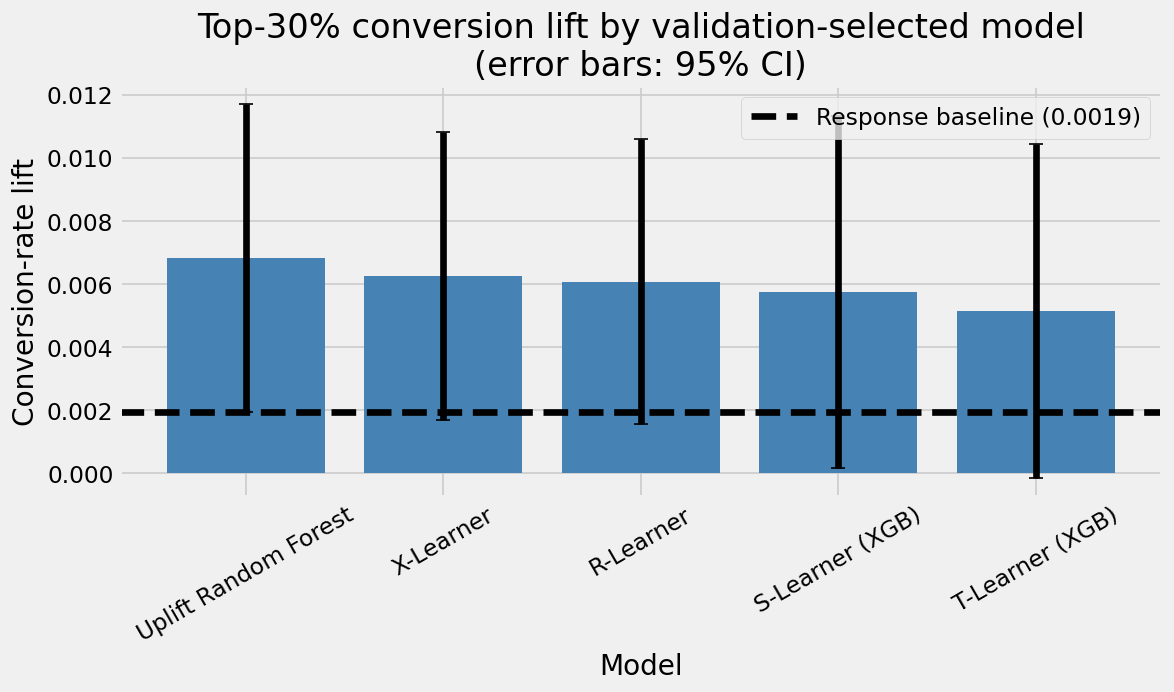

In [5]:
plot_df = uplift_table[[
    "incremental_conversion_rate", "incremental_conversion_rate_ci_lower", "incremental_conversion_rate_ci_upper",
]].rename(columns={
    "incremental_conversion_rate": "actual_lift",
    "incremental_conversion_rate_ci_lower": "actual_lift_ci_lower",
    "incremental_conversion_rate_ci_upper": "actual_lift_ci_upper",
})
plot_df.index = [i.replace("uplift:", "") for i in plot_df.index]
plot_df["actual_lift_se"] = (plot_df["actual_lift_ci_upper"] - plot_df["actual_lift_ci_lower"]) / (2 * 1.96)
# plot_decile_lift_bar draws its reference line at the "Overall" row -> use the response baseline
plot_df.loc["Overall"] = [
    float(baseline_row["incremental_conversion_rate"]),
    float(baseline_row["incremental_conversion_rate_ci_lower"]),
    float(baseline_row["incremental_conversion_rate_ci_upper"]),
    float(baseline_row["incremental_conversion_rate_ci_upper"] - baseline_row["incremental_conversion_rate_ci_lower"]) / (2 * 1.96),
]

fig = plot_decile_lift_bar(
    plot_df,
    title="Top-30% conversion lift by validation-selected model",
    xlabel="Model",
    figsize=(10, 6),
)
ax = fig.axes[0]
ax.set_ylabel("Conversion-rate lift")
ax.tick_params(axis="x", rotation=30)
handles, labels = ax.get_legend_handles_labels()
labels = [label.replace("Overall ATE", "Response baseline") for label in labels]
ax.legend(handles, labels, loc="upper right")
fig.tight_layout()
save_fig(fig, "roi_policy_cross_model_lift.png")

## Summary and interpretation

The printout below summarizes the OOF-selected model from each family. Two results should be read side by side:

- **`net_value` (held-out conversion outcome)** — the observed policy-evaluation result at the fixed top-30% volume.
- **`validation_qini_visit` (OOF visit outcome)** — the leakage-free ranking evidence used before the test set was read.

These can **disagree** because the models rank *visit* uplift while policy value is measured using *conversion*. The largest held-out value should be treated as exploratory policy-evaluation evidence, not as permission to tune or switch model variants on the test set. The reported 95% intervals are nominal per-policy intervals and are not adjusted for comparing multiple policies; a prospective experiment remains the appropriate deployment check.

In [6]:
baseline_label = f"response_probability:{selected_response}"
uplift_only = roi_simulation.drop(index=baseline_label)
best_profit = uplift_only["net_value"].idxmax().replace("uplift:", "")
best_validation_qini = uplift_only["validation_qini_visit"].idxmax().replace("uplift:", "")
n_sig = int(uplift_only["significant_at_95pct"].sum())
base_sig = bool(roi_simulation.loc[baseline_label, "significant_at_95pct"])

print(f"Validation-selected uplift models compared: {len(uplift_only)}  "
      f"({', '.join(i.replace('uplift:', '') for i in uplift_only.index)})")
print()
bp = "uplift:" + best_profit
print(f"Largest held-out value (top-30%, conversion): {best_profit} "
      f"(${roi_simulation.loc[bp, 'net_value']:,.0f}, lift {roi_simulation.loc[bp, 'incremental_conversion_rate']:.3%}, "
      f"{'significant' if roi_simulation.loc[bp, 'significant_at_95pct'] else 'not significant'})")
bq = "uplift:" + best_validation_qini
print(f"Best OOF visit-uplift ranker:               {best_validation_qini} "
      f"(validation Qini {roi_simulation.loc[bq, 'validation_qini_visit']:.4f}; "
      f"test Qini {roi_simulation.loc[bq, 'test_qini_visit']:.4f})")
print()
if best_profit != best_validation_qini:
    print(f"NOTE: largest held-out policy value ({best_profit}) != best OOF-Qini model "
          f"({best_validation_qini}). Visit-uplift ranking and conversion policy value answer different questions.")
else:
    print(f"Largest held-out policy value and best OOF Qini agree ({best_profit}) this run.")
print()
print(f"{n_sig} of {len(uplift_only)} models show a top-30% conversion lift whose 95% CI excludes zero "
      f"(response-probability baseline: {'significant' if base_sig else 'not distinguishable from zero'}).")
print()
print("The test-set policy comparison is final evaluation evidence; model variants remain fixed by OOF validation.")

Validation-selected uplift models compared: 5  (Uplift Random Forest, X-Learner, R-Learner, S-Learner (XGB), T-Learner (XGB))

Largest held-out value (top-30%, conversion): Uplift Random Forest ($3,462, lift 0.681%, significant)
Best OOF visit-uplift ranker:               T-Learner (XGB) (validation Qini 0.0808; test Qini 0.0524)

NOTE: largest held-out policy value (Uplift Random Forest) != best OOF-Qini model (T-Learner (XGB)). Visit-uplift ranking and conversion policy value answer different questions.

4 of 5 models show a top-30% conversion lift whose 95% CI excludes zero (response-probability baseline: not distinguishable from zero).

The test-set policy comparison is final evaluation evidence; model variants remain fixed by OOF validation.
